In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from sklearn.preprocessing import MinMaxScaler

c:\Users\prasa\Desktop\internship\sales-forecasting-system\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
weekly_sales = pd.read_csv(
    "../data/processed/weekly_sales.csv"
)

In [4]:
weekly_sales.columns = ["Date", "Sales"]

weekly_sales["Date"] = pd.to_datetime(
    weekly_sales["Date"]
)

In [5]:
weekly_sales.head()

,Date,Sales
0,2013-01-06,26129335
1,2013-01-13,49275222
2,2013-01-20,34377765
3,2013-01-27,46040169
4,2013-02-03,38466029


In [6]:
train_size = int(
    len(weekly_sales) * 0.8
)

train = weekly_sales[:train_size]

test = weekly_sales[train_size:]

In [7]:
print(train.shape)
print(test.shape)

(108, 2)
(27, 2)


In [8]:
arima_model = ARIMA(
    train["Sales"],
    order=(1,0,1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  108
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1855.407
Date:                Wed, 17 Jun 2026   AIC                           3718.815
Time:                        12:30:11   BIC                           3729.543
Sample:                             0   HQIC                          3723.165
                                - 108                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.289e+07   6.05e+05     70.920      0.000    4.17e+07    4.41e+07
ar.L1         -0.8060      0.101     -8.000      0.000      -1.003      -0.608
ma.L1          0.4686      0.159      2.948      0.0

In [9]:
arima_forecast = arima_fit.forecast(
    steps=len(test)
)

In [10]:
arima_forecast.head()

108    4.566097e+07
109    4.065416e+07
110    4.468944e+07
111    4.143717e+07
112    4.405836e+07
Name: predicted_mean, dtype: float64

In [11]:
mae_arima = mean_absolute_error(
    test["Sales"],
    arima_forecast
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test["Sales"],
        arima_forecast
    )
)

print("ARIMA MAE :", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE : 6910390.9162063785
ARIMA RMSE: 7567086.103054329


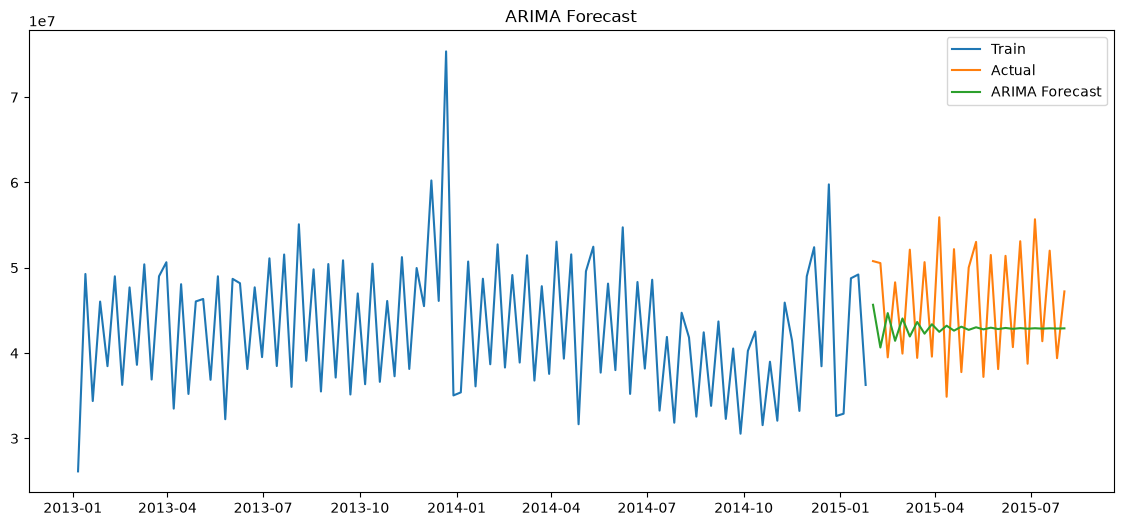

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    train["Date"],
    train["Sales"],
    label="Train"
)

plt.plot(
    test["Date"],
    test["Sales"],
    label="Actual"
)

plt.plot(
    test["Date"],
    arima_forecast,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast")

plt.legend()

plt.savefig(
    "../dashboard/screenshots/arima_actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

In [14]:
prophet_df = weekly_sales.copy()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2013-01-06,26129335
1,2013-01-13,49275222
2,2013-01-20,34377765
3,2013-01-27,46040169
4,2013-02-03,38466029


In [15]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(prophet_df)

12:39:19 - cmdstanpy - INFO - Chain [1] start processing
12:39:19 - cmdstanpy - INFO - Chain [1] done processing


In [16]:
future = prophet_model.make_future_dataframe(
    periods=27,
    freq="W"
)

future.tail()

,ds
157,2016-01-10
158,2016-01-17
159,2016-01-24
160,2016-01-31
161,2016-02-07


In [17]:
forecast = prophet_model.predict(future)

In [18]:
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
157,2016-01-10,3.921250e+07,2.942926e+07,4.890005e+07
158,2016-01-17,4.202474e+07,3.253265e+07,5.124835e+07
159,2016-01-24,4.517549e+07,3.585607e+07,5.514831e+07
160,2016-01-31,4.616521e+07,3.610699e+07,5.555741e+07
161,2016-02-07,4.530934e+07,3.526566e+07,5.518265e+07


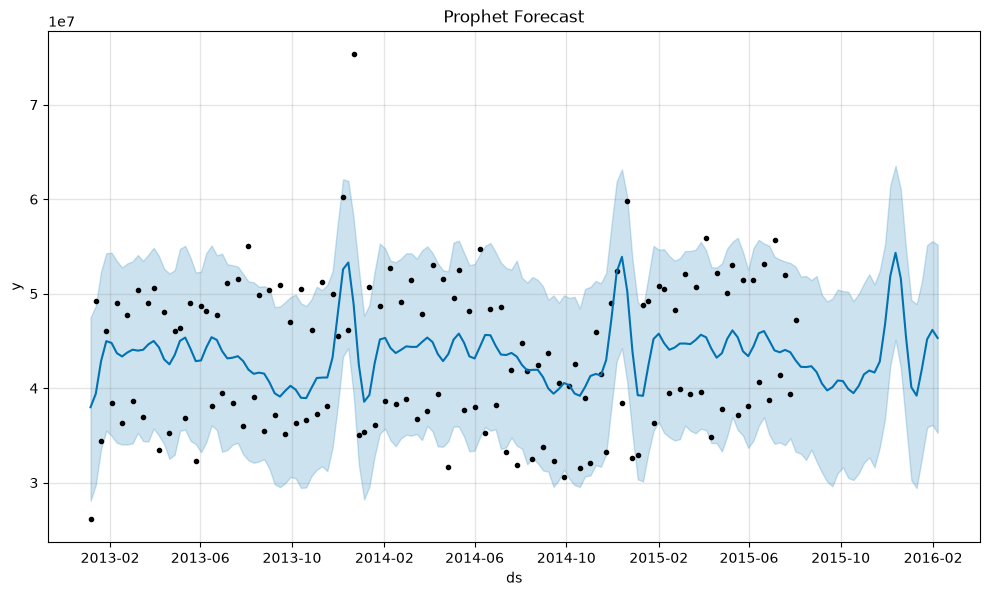

In [19]:
fig = prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.savefig(
    "../dashboard/screenshots/prophet_forecast.png",
    bbox_inches="tight"
)

plt.show()

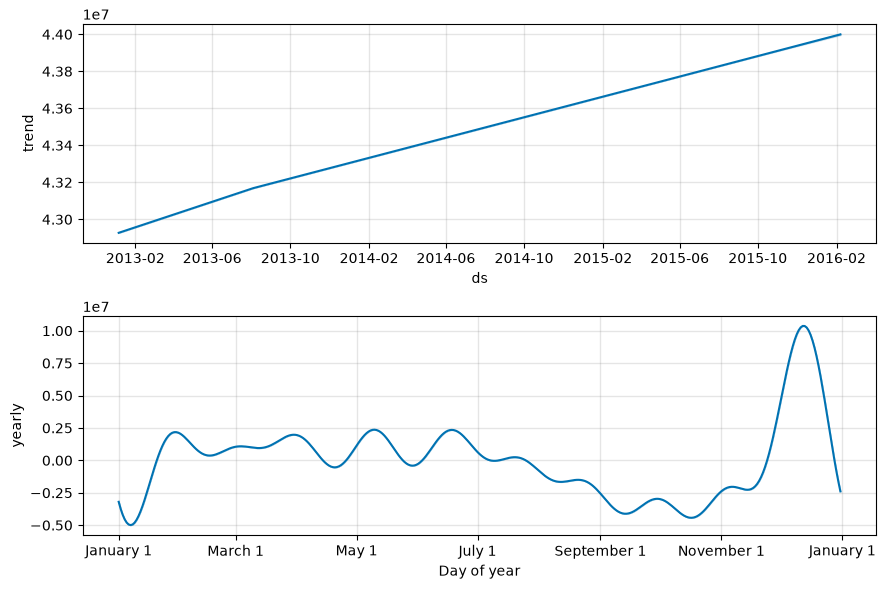

In [20]:
fig2 = prophet_model.plot_components(
    forecast
)

plt.savefig(
    "../dashboard/screenshots/prophet_components.png",
    bbox_inches="tight"
)

plt.show()

In [21]:
prophet_predictions = (
    forecast["yhat"]
    .iloc[-len(test):]
    .values
)

In [22]:
mae_prophet = mean_absolute_error(
    test["Sales"],
    prophet_predictions
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test["Sales"],
        prophet_predictions
    )
)

print("Prophet MAE :", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

Prophet MAE : 6901725.716767605
Prophet RMSE: 8335014.366483907


In [23]:
import pickle

with open(
    "../models/prophet_model.pkl",
    "wb"
) as file:
    pickle.dump(
        prophet_model,
        file
    )

In [24]:
lstm_data = weekly_sales[["Sales"]].copy()

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    lstm_data
)

In [26]:
sequence_length = 12

X = []
y = []

for i in range(
    sequence_length,
    len(scaled_data)
):
    X.append(
        scaled_data[
            i-sequence_length:i,
            0
        ]
    )

    y.append(
        scaled_data[i,0]
    )

X = np.array(X)
y = np.array(y)

In [27]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)
print(y.shape)

(123, 12, 1)
(123,)


In [28]:
split_index = int(
    len(X) * 0.8
)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            1
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(50)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(1)
)

c:\Users\prasa\Desktop\internship\sales-forecasting-system\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(
        X_test,
        y_test
    ),
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.1184 - val_loss: 0.0523
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0363 - val_loss: 0.0284
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0367 - val_loss: 0.0194
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0301 - val_loss: 0.0251
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0271 - val_loss: 0.0220
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0264 - val_loss: 0.0202
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0268 - val_loss: 0.0194
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0259 - val_loss: 0.0194
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0295 - val_loss: 0.0221
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0278 - val_loss: 0.0199
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0281 - val_loss: 0.0193
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0278 - val_loss: 0.0218
E

In [32]:
predictions = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


In [33]:
predictions = scaler.inverse_transform(
    predictions
)

actual_values = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [34]:
mae_lstm = mean_absolute_error(
    actual_values,
    predictions
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        actual_values,
        predictions
    )
)

print("LSTM MAE :", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE : 6510116.0
LSTM RMSE: 6849695.960555142


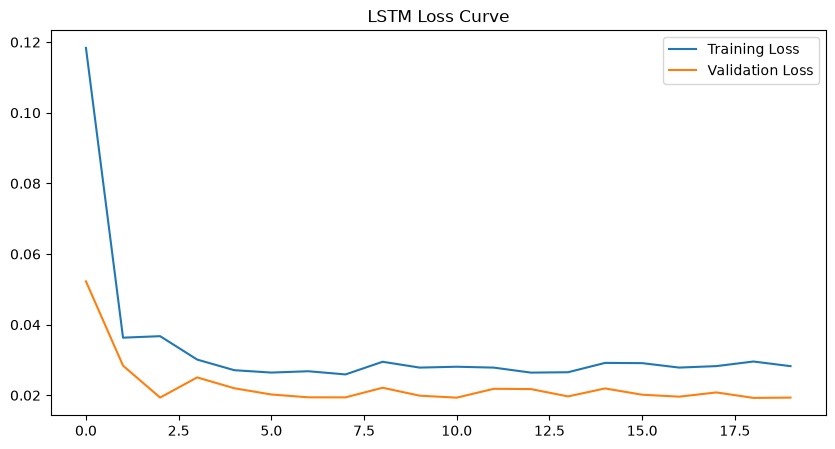

In [35]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Loss Curve")

plt.legend()

plt.savefig(
    "../dashboard/screenshots/lstm_loss_curve.png",
    bbox_inches="tight"
)

plt.show()

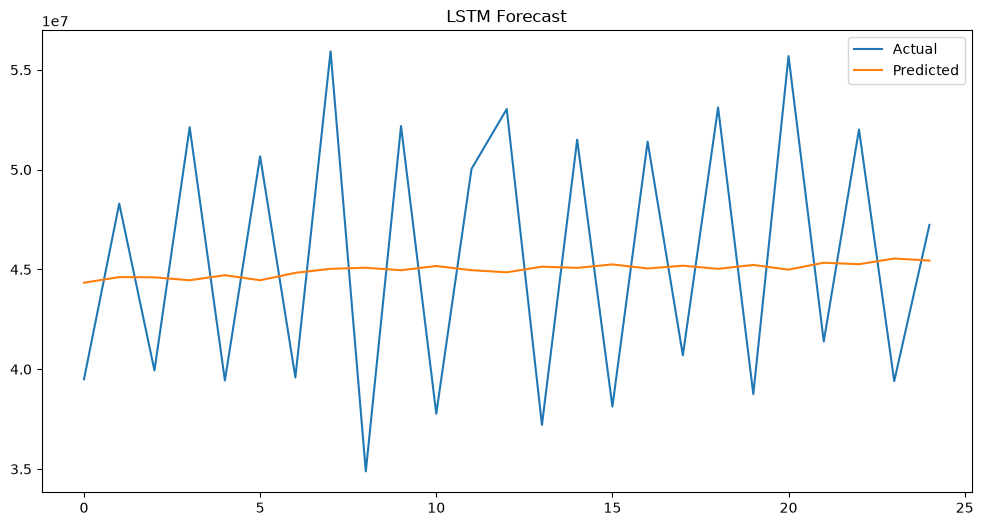

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    actual_values,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.title("LSTM Forecast")

plt.legend()

plt.savefig(
    "../dashboard/screenshots/lstm_actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
model.save(
    "../models/lstm_model.keras"
)

In [38]:
import pickle

with open(
    "../models/arima_model.pkl",
    "wb"
) as file:
    pickle.dump(
        arima_fit,
        file
    )

print("ARIMA model saved successfully")

ARIMA model saved successfully


In [39]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "LSTM"],
    "MAE": [
        mae_arima,
        mae_prophet,
        mae_lstm
    ],
    "RMSE": [
        rmse_arima,
        rmse_prophet,
        rmse_lstm
    ]
})

comparison

,Model,MAE,RMSE
0,ARIMA,6.910391e+06,7.567086e+06
1,Prophet,6.901726e+06,8.335014e+06
2,LSTM,6.510116e+06,6.849696e+06


In [40]:
comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

<Figure size 1000x600 with 0 Axes>

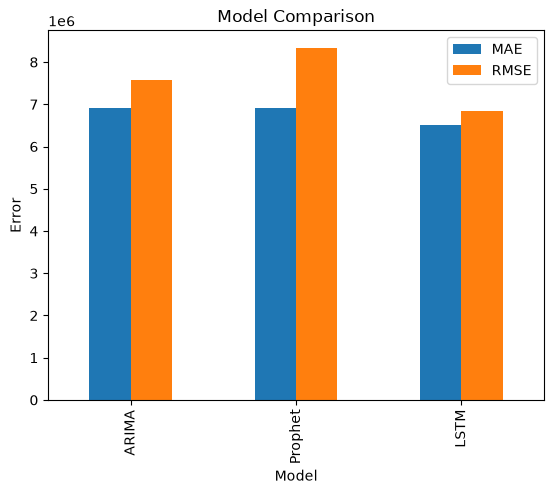

In [41]:
plt.figure(figsize=(10,6))

comparison.set_index(
    "Model"
)[["MAE","RMSE"]].plot(
    kind="bar"
)

plt.title("Model Comparison")

plt.ylabel("Error")

plt.savefig(
    "../dashboard/screenshots/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [42]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

print(best_model)

Model              LSTM
MAE           6510116.0
RMSE     6849695.960555
Name: 2, dtype: object


# Best Model Selection

Based on model evaluation metrics:

- ARIMA RMSE = 7,567,086.10
- Prophet RMSE = 8,335,014.37
- LSTM RMSE = 6,849,695.96

The LSTM model achieved the lowest RMSE and MAE values.

Therefore, LSTM is selected as the best-performing forecasting model for this project.